# Student Time Management — Data Analysis & Cleaning

---

In this notebook we will load, clean, and visualize a survey dataset about how students manage their time between studying and leisure.

**The notebook is divided into two parts:**
1. **Data Cleaning:** Fix column names, handle inconsistent values, and deal with checkbox questions.
2. **Data Visualization:** Use Matplotlib and Seaborn to explore the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Load and Explore the Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Student Time Management_ Studying and Leisure Activities.csv to Student Time Management_ Studying and Leisure Activities.csv


In [3]:
df = pd.read_csv('Student Time Management_ Studying and Leisure Activities.csv')
df.head()

,Timestamp,What is your gender?,What is your major/field of study?,What is your current year of study?,Are you a full-time student?,How often do you feel stressed because of your academic workload?,"On average, how many hours per day do you spend on leisure activities?",Which leisure activity do you spend the most time on?,How often do leisure activities interfere with your study time?,Do you think you manage your time effectively between studying and leisure?,Which area takes more of your daily time?,How satisfied are you with your current balance between studying and leisure?,Do you believe better time management would improve your academic performance?,Would you like to improve the balance between your study time and leisure time?
0,2026/04/05 5:26:21 PM GMT+2,Male,Computer Science,Second year,Yes,Often,3–4 hours,Social media,Always,No,Leisure activities,Neutral,Yes,Yes
1,2026/04/05 5:27:02 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,1–2 hours,Hanging out with friends,Maybe,Yes,Leisure activities,Neutral,Yes,Yes
2,2026/04/05 5:29:32 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,3–4 hours,Reading for pleasure,Always,No,Leisure activities,Satisfied,Yes,No
3,2026/04/05 5:30:35 PM GMT+2,Female,Computer Science,Second year,No,Often,3–4 hours,Watching TV / movies,Often,Yes,Both equally,Neutral,Yes,Yes
4,2026/04/05 5:31:52 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,3–4 hours,Sports / exercise,Often,Yes,Both equally,Satisfied,Yes,Yes


In [4]:
df.shape

(60, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 14 columns):
 #   Column                                                                            Non-Null Count  Dtype 
---  ------                                                                            --------------  ----- 
 0   Timestamp                                                                         60 non-null     object
 1   What is your gender?                                                              60 non-null     object
 2   What is your major/field of study?                                                60 non-null     object
 3     What is your current year of study?                                             60 non-null     object
 4   Are you a full-time student?                                                      60 non-null     object
 5   How often do you feel stressed because of your academic workload?                 60 non-null     object
 6   On average, 

In [6]:
# Check for missing values
df.isnull().sum()

,0
Timestamp,0
What is your gender?,0
What is your major/field of study?,0
What is your current year of study?,0
Are you a full-time student?,0
How often do you feel stressed because of your academic workload?,0
"On average, how many hours per day do you spend on leisure activities?",0
Which leisure activity do you spend the most time on?,0
How often do leisure activities interfere with your study time?,0
Do you think you manage your time effectively between studying and leisure?,0


In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## Part 2: Data Cleaning

### 2.1 Clean Column Names

Some column names have extra spaces and are too long. We will strip spaces and rename them to shorter names.

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()
df.columns

Index(['Timestamp', 'What is your gender?',
       'What is your major/field of study?',
       'What is your current year of study?', 'Are you a full-time student?',
       'How often do you feel stressed because of your academic workload?',
       'On average, how many hours per day do you spend on leisure activities?',
       'Which leisure activity do you spend the most time on?',
       'How often do leisure activities interfere with your study time?',
       'Do you think you manage your time effectively between studying and leisure?',
       'Which area takes more of your daily time?',
       'How satisfied are you with your current balance between studying and leisure?',
       'Do you believe better time management would improve your academic performance?',
       'Would you like to improve the balance between your study time and leisure time?'],
      dtype='object')

In [9]:
# Rename to shorter, easier column names
df.rename(columns={
    'Timestamp': 'timestamp',
    'What is your gender?': 'gender',
    'What is your major/field of study?': 'major',
    'What is your current year of study?': 'year',
    'Are you a full-time student?': 'full_time',
    'How often do you feel stressed because of your academic workload?': 'stress',
    'On average, how many hours per day do you spend on leisure activities?': 'leisure_hours',
    'Which leisure activity do you spend the most time on?': 'leisure_activity',
    'How often do leisure activities interfere with your study time?': 'interference',
    'Do you think you manage your time effectively between studying and leisure?': 'manages_time',
    'Which area takes more of your daily time?': 'time_dominant',
    'How satisfied are you with your current balance between studying and leisure?': 'satisfaction',
    'Do you believe better time management would improve your academic performance?': 'mgmt_helps',
    'Would you like to improve the balance between your study time and leisure time?': 'wants_improvement'
}, inplace=True)

df.head()

,timestamp,gender,major,year,full_time,stress,leisure_hours,leisure_activity,interference,manages_time,time_dominant,satisfaction,mgmt_helps,wants_improvement
0,2026/04/05 5:26:21 PM GMT+2,Male,Computer Science,Second year,Yes,Often,3–4 hours,Social media,Always,No,Leisure activities,Neutral,Yes,Yes
1,2026/04/05 5:27:02 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,1–2 hours,Hanging out with friends,Maybe,Yes,Leisure activities,Neutral,Yes,Yes
2,2026/04/05 5:29:32 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,3–4 hours,Reading for pleasure,Always,No,Leisure activities,Satisfied,Yes,No
3,2026/04/05 5:30:35 PM GMT+2,Female,Computer Science,Second year,No,Often,3–4 hours,Watching TV / movies,Often,Yes,Both equally,Neutral,Yes,Yes
4,2026/04/05 5:31:52 PM GMT+2,Male,Computer Science,Second year,Yes,Sometimes,3–4 hours,Sports / exercise,Often,Yes,Both equally,Satisfied,Yes,Yes


### 2.2 Clean the `major` Column

This is a free-text column — students typed their major themselves, so there are inconsistencies like different capitalizations, Arabic text, and very specific values. We need to standardize them.

In [10]:
# See all unique values first
df['major'].value_counts()

,count
major,
Computer Science,32
Engineering,10
Business,9
BIS,1
فنون تطبيقية,1
medicine,1
dentistry,1
Mass communication,1
Still in highschool senior year,1


In [11]:
# Fix inconsistent values
df['major'] = df['major'].replace({
    'BIS'                              : 'Computer Science',
    'Cyber security and ethical hacking': 'Computer Science',
    'Digital Arts'                     : 'Arts & Design',
    'فنون تطبيقية'                     : 'Arts & Design',    # Arabic: Applied Arts
    'Mass communication'               : 'Media & Communication',
    'medicine'                         : 'Medicine',          # fix lowercase
    'dentistry'                        : 'Medicine',
    'Still in highschool senior year'  : 'Other'
})

df['major'].value_counts()

,count
major,
Computer Science,33
Engineering,10
Business,9
Medicine,3
Arts & Design,2
Mass communication,1
Other,1
Cyber security and ethical hacking,1


### 2.3 Handle the Checkbox Question: `leisure_activity`

This question allowed students to **select multiple answers**. The answers are stored in one cell separated by `;`

For example: `Social media;Gaming;Sports / exercise`

We will create a **separate column for each activity** where 1 means the student selected it, and 0 means they did not.

In [12]:
# See the raw values
df['leisure_activity'].value_counts()

,count
leisure_activity,
Social media;Watching TV / movies,5
Social media;Watching TV / movies;Hanging out with friends,5
Social media;Watching TV / movies;Gaming;Sports / exercise;Hanging out with friends,4
Social media;Hanging out with friends,4
Social media;Gaming;Sports / exercise,3
Social media;Gaming;Hanging out with friends,3
Hanging out with friends,3
Social media;Gaming;Sports / exercise;Hanging out with friends,3
Social media;Sports / exercise,3


In [13]:
# For each activity, create a new column: 1 if selected, 0 if not
df['act_social_media']     = df['leisure_activity'].str.contains('Social media',           regex=False).astype(int)
df['act_watching_tv']      = df['leisure_activity'].str.contains('Watching TV / movies',   regex=False).astype(int)
df['act_gaming']           = df['leisure_activity'].str.contains('Gaming',                 regex=False).astype(int)
df['act_sports']           = df['leisure_activity'].str.contains('Sports / exercise',      regex=False).astype(int)
df['act_hanging_out']      = df['leisure_activity'].str.contains('Hanging out with friends',regex=False).astype(int)
df['act_reading']          = df['leisure_activity'].str.contains('Reading for pleasure',   regex=False).astype(int)

# Check the result
df[['leisure_activity', 'act_social_media', 'act_watching_tv', 'act_gaming',
    'act_sports', 'act_hanging_out', 'act_reading']].head(10)

,leisure_activity,act_social_media,act_watching_tv,act_gaming,act_sports,act_hanging_out,act_reading
0,Social media,1,0,0,0,0,0
1,Hanging out with friends,0,0,0,0,1,0
2,Reading for pleasure,0,0,0,0,0,1
3,Watching TV / movies,0,1,0,0,0,0
4,Sports / exercise,0,0,0,1,0,0
5,Hanging out with friends,0,0,0,0,1,0
6,Gaming,0,0,1,0,0,0
7,Sports / exercise,0,0,0,1,0,0
8,Social media;Watching TV / movies;Gaming,1,1,1,0,0,0
9,Social media;Watching TV / movies,1,1,0,0,0,0


In [14]:
# How many students selected each activity?
activity_cols = ['act_social_media', 'act_watching_tv', 'act_gaming',
                 'act_sports', 'act_hanging_out', 'act_reading']

df[activity_cols].sum()

,0
act_social_media,45
act_watching_tv,26
act_gaming,28
act_sports,20
act_hanging_out,29
act_reading,7


---

## Part 3: Data Visualization

### 3.1 Gender Distribution

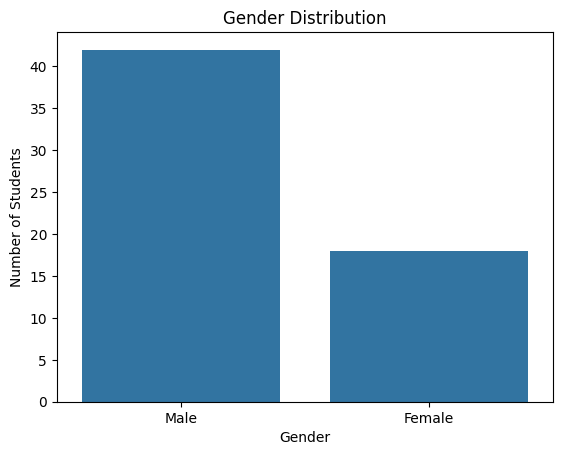

In [15]:
sns.countplot(data=df, x='gender')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')

plt.show()

### 3.2 Major Distribution

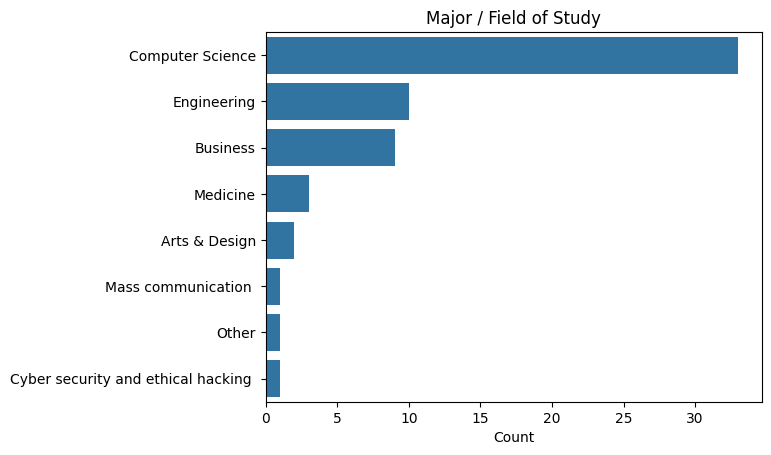

In [31]:
order = df['major'].value_counts().index

sns.countplot(data=df, y='major', order=order)

plt.title('Major / Field of Study')
plt.xlabel('Count')
plt.ylabel('')

plt.show()

### 3.3 Year of Study Distribution

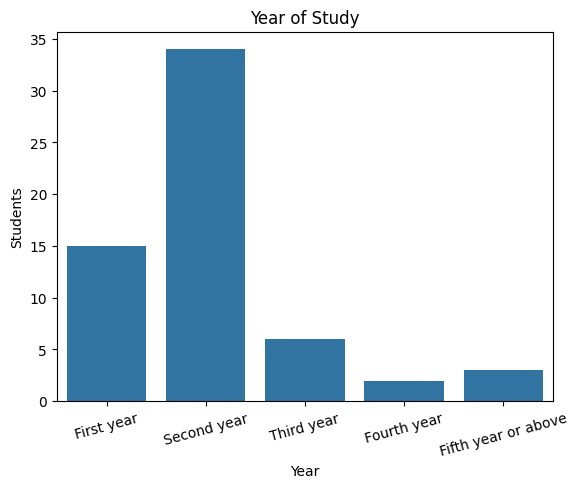

In [17]:
order = ['First year', 'Second year', 'Third year', 'Fourth year', 'Fifth year or above']

sns.countplot(data=df, x='year', order=order)

plt.title('Year of Study')
plt.xlabel('Year')
plt.ylabel('Students')
plt.xticks(rotation=15)

plt.show()

### 3.4 Stress Level

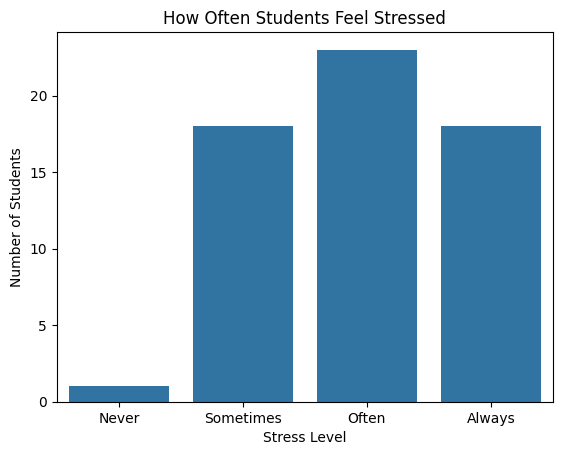

In [30]:
order = ['Never', 'Sometimes', 'Often', 'Always']

sns.countplot(data=df, x='stress', order=order)

plt.title('How Often Students Feel Stressed')
plt.xlabel('Stress Level')
plt.ylabel('Number of Students')

plt.show()

### 3.5 Daily Leisure Hours

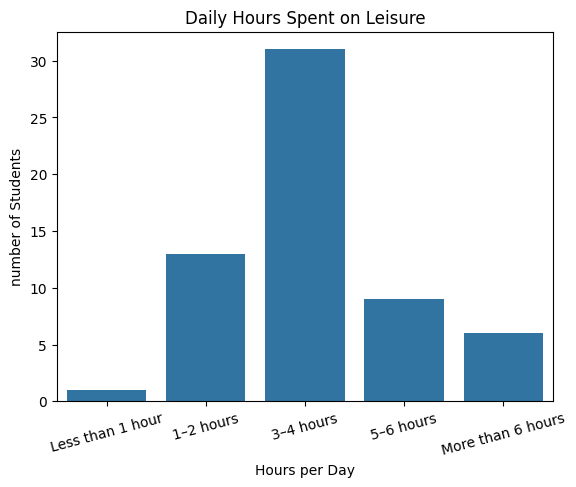

In [29]:
order = ['Less than 1 hour', '1–2 hours', '3–4 hours', '5–6 hours', 'More than 6 hours']

sns.countplot(data=df, x='leisure_hours', order=order)

plt.title('Daily Hours Spent on Leisure')
plt.xlabel('Hours per Day')
plt.ylabel('number of Students')
plt.xticks(rotation=15)

plt.show()

### 3.6 Most Popular Leisure Activities

Because this was a checkbox question, we use the new columns we created to count how many students selected each activity.

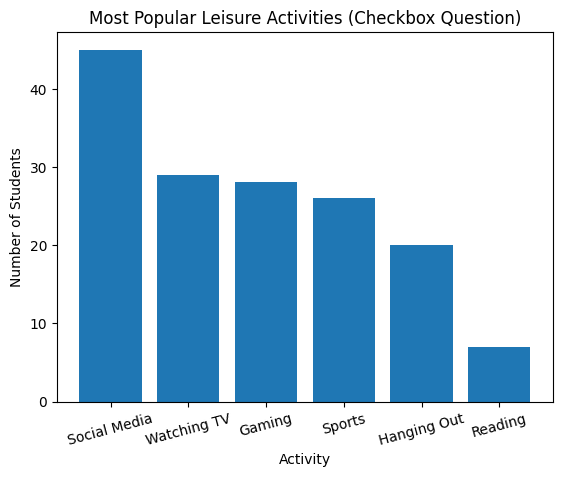

In [20]:
# Count how many students selected each activity
activity_counts = df[activity_cols].sum().sort_values(ascending=False)

# Clean up the labels for display
activity_counts.index = ['Social Media', 'Watching TV', 'Gaming',
                         'Sports', 'Hanging Out', 'Reading']

plt.bar(activity_counts.index, activity_counts.values)

plt.title('Most Popular Leisure Activities (Checkbox Question)')
plt.xlabel('Activity')
plt.ylabel('Number of Students')
plt.xticks(rotation=15)

plt.show()

### 3.7 Leisure Interference with Study Time

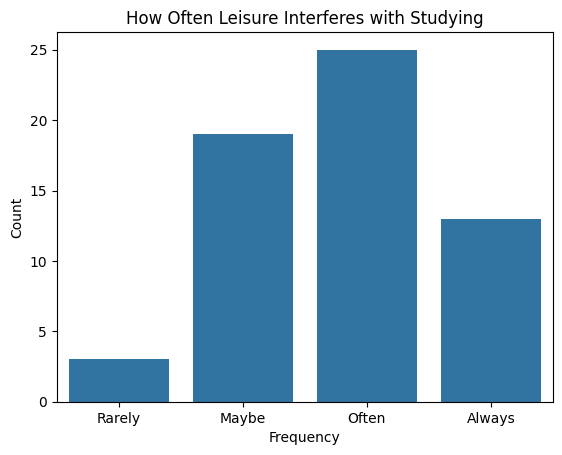

In [21]:
order = ['Rarely', 'Maybe', 'Often', 'Always']

sns.countplot(data=df, x='interference', order=order)

plt.title('How Often Leisure Interferes with Studying')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.show()

### 3.8 Which Area Takes More Daily Time?

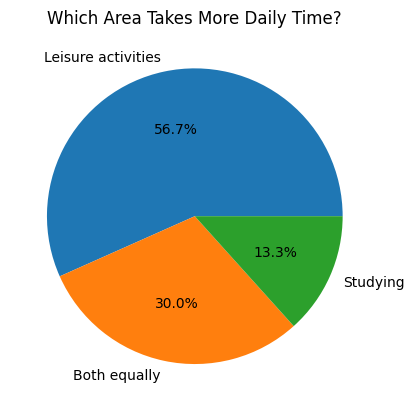

In [22]:
counts = df['time_dominant'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title('Which Area Takes More Daily Time?')

plt.show()

### 3.9 Satisfaction with Study-Leisure Balance

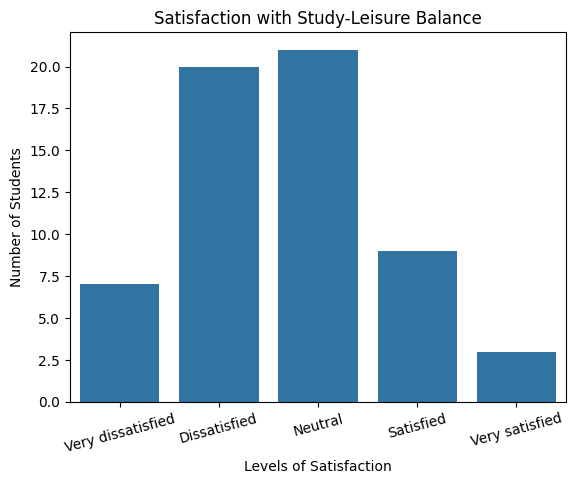

In [27]:
order = ['Very dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very satisfied']

sns.countplot(data=df, x='satisfaction', order=order)

plt.title('Satisfaction with Study-Leisure Balance')
plt.xlabel('Levels of Satisfaction')
plt.ylabel('Number of Students')
plt.xticks(rotation=15)

plt.show()

### 3.10 Stress vs. Leisure Interference (Heatmap)

We can use a crosstab + heatmap to see the relationship between two categorical variables, just like a 2D frequency table.

In [24]:
# Create a crosstab (frequency table)
cross = pd.crosstab(df['stress'], df['interference'])
cross

interference,Always,Maybe,Often,Rarely
stress,,,,
Always,5,7,6,0
Never,0,0,0,1
Often,4,7,12,0
Sometimes,4,5,7,2


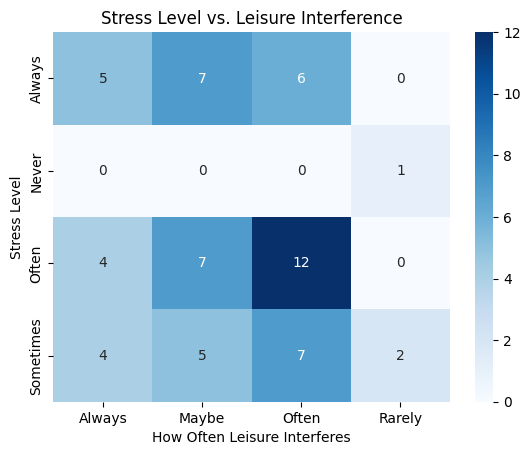

In [25]:
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')

plt.title('Stress Level vs. Leisure Interference')
plt.xlabel('How Often Leisure Interferes')
plt.ylabel('Stress Level')

plt.show()